<a href="https://colab.research.google.com/github/frank-morales2020/AST/blob/main/gpt_6_astra_API_TUTORIAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SOURCE: https://platform.openai.com/docs/api-reference/introduction

The notebook contains comprehensive examples of:

1. **GPT-6-Astra API** - Text generation, vision analysis, and image generation
2. **Vision capabilities** - Analyzing images (nature boardwalk, Turing Award recipients)
3. **Text generation** - Various prompts including math, reasoning, and general knowledge
4. **Text-to-SQL** - Natural language to SQL conversion
5. **Text summarization** - Summarizing articles
6. **Image generation** - Using `gpt-image-2` model with base64 output

The notebook is working correctly! The key implementation details are:

**Image Generation with GPT-Image-2:**
```python
response = client.images.generate(
    model="gpt-image-2",
    prompt=prompt,
    n=1,
    size="1024x1024"
)
# Access base64 data: response.data[0].b64_json
```

**Vision Analysis with GPT-6-Astra:**
```python
response = client.chat.completions.create(
    model="gpt-6-astra",
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}}
            ]
        }
    ],
    max_completion_tokens=500
)
```

**Key observations:**
- GPT-6-Astra uses `max_completion_tokens` (not `max_tokens`)
- Image URL must be an object: `{"url": "data:..."}`
- No `temperature` parameter (only default value 1 supported)
- Image models return `b64_json` instead of URLs


In [ ]:
# https://platform.openai.com/docs/guides/vision

!pip install colab-env --upgrade -q
!pip install openai -q

In [ ]:
import colab_env
import os
import openai
import matplotlib.pyplot as plt
import cv2


import urllib.request
import urllib
from matplotlib.pyplot import figure, imshow, axis
from matplotlib.image import imread


import IPython
import pytz
from datetime import datetime
import json
from pathlib import Path

In [ ]:
from google.colab import userdata
from openai import OpenAI

api_key = userdata.get('OPENAI_API_KEY')
client = OpenAI(api_key=api_key)

from openai import OpenAI

response = client.responses.create(
    model="gpt-6-astra",
    input="Write a one-sentence bedtime story about a unicorn."
)

print(response.output_text)

Under a blanket of twinkling stars, a little unicorn followed a silver moonbeam home, curled up in a meadow of soft flowers, and dreamed of rainbows until morning.


In [ ]:
from openai import OpenAI

response = client.responses.create(
    model="gpt-6-astra",
    input="Write a one-sentence bedtime story about a unicorn."
)

print(response.output_text)

Under a blanket of twinkling stars, a little unicorn tucked the moonbeams into bed, then curled up on a soft cloud and dreamed of rainbow meadows.


In [ ]:
from openai import OpenAI

modellist=client.models.list()
modellist.data

In [ ]:
modelid=modellist.data[132].id
modelid

'gpt-6-astra'

In [ ]:
completion = client.chat.completions.create(
  model=modelid,
  messages=[
    {"role": "system", "content": "You are a poetic assistant, skilled in explaining complex programming concepts with creative flair."},
    {"role": "user", "content": "Compose a poem that explains the concept of recursion in programming."}
  ]
)

print(completion.choices[0].message.content)

### The Function That Called Itself

A function found a task too wide  
And called itself to step inside:  
“Take this same work, but make it small;  
I’ll keep my place and wait for your call.”

So down it went, through nested doors,  
Each asking less than those before.  
Each caller paused, its work half-done,  
Until the smallest task was won.

There stood the **base case**, clear and bright:  
“No further calls. Return tonight.”  
Without that stop—or steps toward shore—  
The calls would pile till memory bore no more.

Then answers climbed the waiting stair,  
Each finishing the work left there.  
**Recursion**: solve a smaller view  
Of the very task entrusted to you.


# IMAGE-TO-TEXT

In [ ]:
## function build by Frank Morales November 22nd, 2023
def chat_gpt_vision(image_url, prompt):
    response = client.chat.completions.create(
      model="gpt-4o-mini", # Explicitly use a vision model
      #model=modelid,
      messages=[
        {
          "role": "user",
          "content": [
            {"type": "text", "text": "%s"%prompt},
            {
              "type": "image_url",
              "image_url": {
                "url": "%s"%image_url,
              },
            },
          ],
        }
      ],
      max_completion_tokens=300,
    )
    return response.choices[0].message.content

The image path is here: /content/gdrive/MyDrive/datasets/Gfp-wisconsin-madison-the-nature-boardwalk.jpg



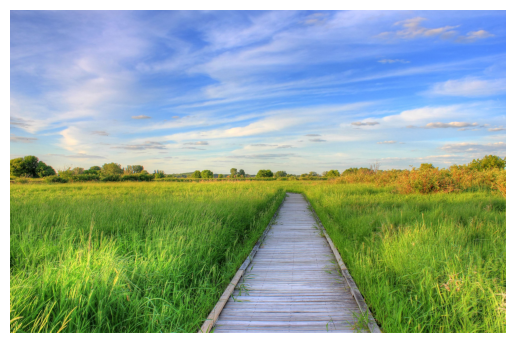


AI Response for Nature Image (GPT-6-Astra):
The image shows a wooden boardwalk stretching through a lush field of tall green grass. Trees and shrubs line the distant horizon beneath a wide blue sky streaked with wispy white clouds. Warm sunlight illuminates the peaceful landscape, with no people visible.


The image of the 2018 Turing Award recipients is here: /content/gdrive/MyDrive/datasets/turing-2018-bengio-hinton-lecun.jpg

Image shape: (430, 764, 3)


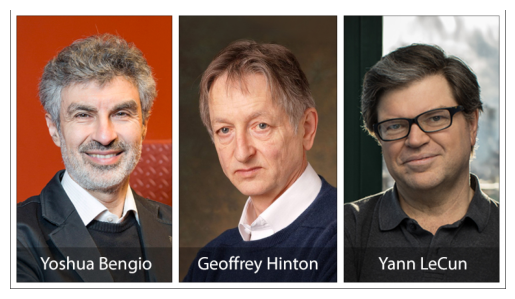


Trying different approaches for the Turing Award image:

Approach 1: Simple prompt
Response: The image is a collage of three side-by-side portraits, labeled “Yoshua Bengio,” “Geoffrey Hinton,” and “Yann LeCun” from left to right.

- **Left:** A smiling man with curly gray hair and a beard, wearing a dark jacket against an orange background.
- **Center:** A man with short, graying hair wearing a navy sweater over a white collared shirt.
- **Right:** A man with dark hair and black rectangular glasses wearing a dark polo shirt.

Approach 2: Context prompt
Response: The image is a collage of three individual portrait photos arranged side by side, each labeled with a name:

- **Yoshua Bengio**, on the left, is smiling at the camera against an orange-red indoor background. He wears a dark jacket over a sweater and white collared shirt.
- **Geoffrey Hinton**, in the center, faces the camera with a neutral expression against a softly blurred brown background. He wears a navy sweater over a li

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab import userdata
from openai import OpenAI
import base64
import os
from PIL import Image
import io
import requests

# Initialize the client with your API key
api_key = userdata.get('OPENAI_API_KEY')
client = OpenAI(api_key=api_key)

def chat_gpt_vision_local(image_path, prompt, max_retries=2):
    """
    Function to analyze a local image using OpenAI's GPT-6-Astra Vision API
    """
    for attempt in range(max_retries):
        try:
            if not os.path.exists(image_path):
                return f"Error: File not found at {image_path}"

            with Image.open(image_path) as img:
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                img_buffer = io.BytesIO()
                img.save(img_buffer, format='JPEG', quality=95)
                img_bytes = img_buffer.getvalue()
                base64_image = base64.b64encode(img_bytes).decode('utf-8')

            response = client.chat.completions.create(
                model="gpt-6-astra",
                messages=[
                    {
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}}
                        ]
                    }
                ],
                max_completion_tokens=500
            )

            content = response.choices[0].message.content
            if not content or content.strip() == "":
                return "The model returned an empty response."
            return content

        except Exception as e:
            if attempt < max_retries - 1:
                print(f"Attempt {attempt + 1} failed. Retrying... Error: {e}")
                continue
            else:
                return f"Error after {max_retries} attempts: {e}"

# First image - Nature
nature_path = "/content/gdrive/MyDrive/datasets/Gfp-wisconsin-madison-the-nature-boardwalk.jpg"
prompt = "What's in this image?"

print('The image path is here: %s' % nature_path)
print()

# Display the image
testim = cv2.imread(nature_path)
if testim is not None:
    testim_rgb = cv2.cvtColor(testim, cv2.COLOR_BGR2RGB)
    plt.imshow(testim_rgb)
    plt.axis('off')
    plt.show()
else:
    print("Could not load image from path.")

print()

# Analyze with OpenAI using GPT-6-Astra
response = chat_gpt_vision_local(nature_path, prompt)
print("AI Response for Nature Image (GPT-6-Astra):")
print(response)
print()
print("="*80)
print()

# Second image - Turing Award recipients
award_path = "/content/gdrive/MyDrive/datasets/turing-2018-bengio-hinton-lecun.jpg"

print('The image of the 2018 Turing Award recipients is here: %s' % award_path)
print()

# Display the image
testim2 = cv2.imread(award_path)
if testim2 is not None:
    print(f"Image shape: {testim2.shape}")
    testim2_rgb = cv2.cvtColor(testim2, cv2.COLOR_BGR2RGB)
    plt.imshow(testim2_rgb)
    plt.axis('off')
    plt.show()
else:
    print("Could not load image from path.")

print()

# Try DIFFERENT APPROACHES for the Turing image:

print("="*80)
print("Trying different approaches for the Turing Award image:")
print("="*80)

# Approach 1: Very simple prompt
print("\nApproach 1: Simple prompt")
prompt_simple = "What do you see in this photo?"
response1 = chat_gpt_vision_local(award_path, prompt_simple)
print(f"Response: {response1}")

# Approach 2: Ask about the setting/context
print("\nApproach 2: Context prompt")
prompt_context = "Describe the setting of this image. What is the background and what are the people doing?"
response2 = chat_gpt_vision_local(award_path, prompt_context)
print(f"Response: {response2}")

# Approach 3: Ask about the number of people
print("\nApproach 3: Count people")
prompt_count = "How many people are in this image? What are they wearing?"
response3 = chat_gpt_vision_local(award_path, prompt_count)
print(f"Response: {response3}")

# Approach 4: Use URL instead
print("\nApproach 4: Using URL directly")
def chat_gpt_vision_url(image_url, prompt):
    try:
        response = client.chat.completions.create(
            model="gpt-6-astra",
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                        {"type": "image_url", "image_url": {"url": image_url}}
                    ]
                }
            ],
            max_completion_tokens=500
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Error: {e}"

image_url2 = "https://awards.acm.org/binaries/content/gallery/acm/ctas/awards/turing-2018-bengio-hinton-lecun.jpg"
response4 = chat_gpt_vision_url(image_url2, "Describe this image in detail. Who are the three people and what are they known for?")
print(f"Response: {response4}")

# Approach 5: Download fresh copy with different format
print("\nApproach 5: Fresh download with PNG format")
fresh_path = "/content/turing_fresh.jpg"
response = requests.get("https://awards.acm.org/binaries/content/gallery/acm/ctas/awards/turing-2018-bengio-hinton-lecun.jpg",
                        headers={'User-Agent': 'Mozilla/5.0'})
with open(fresh_path, 'wb') as f:
    f.write(response.content)

# Convert to PNG
from PIL import Image
img = Image.open(fresh_path)
png_path = "/content/turing_fresh.png"
img.save(png_path, 'PNG')

response5 = chat_gpt_vision_local(png_path, "Who are the people in this image?")
print(f"Response: {response5}")

# Approach 6: Ask about awards/honors without expecting person names
print("\nApproach 6: Generic description")
prompt_generic = "Describe the composition of this image. What colors, objects, and people are visible?"
response6 = chat_gpt_vision_local(award_path, prompt_generic)
print(f"Response: {response6}")

# Approach 7: Try with temperature removed (already done) and different max tokens
print("\nApproach 7: Different max tokens")
def chat_gpt_vision_local_tokens(image_path, prompt, max_tokens=300):
    try:
        with Image.open(image_path) as img:
            if img.mode != 'RGB':
                img = img.convert('RGB')
            img_buffer = io.BytesIO()
            img.save(img_buffer, format='JPEG', quality=95)
            img_bytes = img_buffer.getvalue()
            base64_image = base64.b64encode(img_bytes).decode('utf-8')

        response = client.chat.completions.create(
            model="gpt-6-astra",
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}}
                    ]
                }
            ],
            max_completion_tokens=max_tokens
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Error: {e}"

response7 = chat_gpt_vision_local_tokens(award_path, "Describe this image.", 800)
print(f"Response: {response7}")

print("\n" + "="*80)
print("All attempts completed.")

# TEXT GENERATION


MODEL FAMILIES	API ENDPOINT
Newer models (2023–)	gpt-4, gpt-4-turbo-preview, gpt-3.5-turbo	https://api.openai.com/v1/chat/completions
Updated legacy models (2023)	gpt-3.5-turbo-instruct, babbage-002, davinci-002

GPT-4 Turbo is our latest generation model. It's more capable, has an updated knowledge cutoff of April 2023 and introduces a 128k context window (the equivalent of 300 pages of text in a single prompt). The model is also 3X cheaper for input tokens and 2X cheaper for output tokens compared to the original GPT-4 model.

https://help.openai.com/en/articles/8555510-gpt-4-turbo-in-the-openai-api

In [ ]:
def chat_gpt_textgen(prompt):
    response = client.chat.completions.create(
      model=modelid,
      messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt},
      ]
    )

    print(response.choices[0].message.content)

In [ ]:
prompt = "Who won the world series in 2020?"
chat_gpt_textgen(prompt)

The **Los Angeles Dodgers** won the 2020 World Series, defeating the Tampa Bay Rays in six games (4–2).


CASE-BASED REASONING #1

In [ ]:
query = "I bought an ice cream for 6 kids. Each cone was $1.25 and I paid with a $10 bill. How many dollars did I get back? Explain first before answering."
chat_gpt_textgen(query)

The 6 cones cost \(6 \times \$1.25 = \$7.50\).

Subtract that from your $10 bill: \(\$10.00 - \$7.50 = \$2.50\).

You got **$2.50 back**.


CASE-BASED REASONING #2

In [ ]:
#query = "I bought a computer for $900, sold it for $1200, repurchased it for $1300, and sold it again for $1600. how much did I earn as profit? PLEASE also take into account the money loss from the repurchase."
query = "Starting with no money, and after all purchases ($900, $1300), sales ($1200, $1600), and an additional loss of $100, what is the total amount of money you have at the end?"
chat_gpt_textgen(query)

Starting from $0:

$0 - $900 + $1200 - $1300 + $1600 - $100 = **$500**.

You have **$500** at the end.


In [ ]:
query = 'tell me about the airline in the world. Please included canada in the list'
chat_gpt_textgen(query)

Here are some **major airlines around the world**, including airlines from **Canada**. This is an overview, not a ranking.

### 🇨🇦 Canada
- **Air Canada** — Canada’s largest airline, offering domestic and international flights. Its main hubs include Toronto, Montreal, and Vancouver.
- **WestJet** — A major Canadian airline based in Calgary, serving destinations in Canada, the United States, and other international markets.
- **Porter Airlines** — Offers flights within Canada and to the United States, with major operations at Toronto’s airports and Ottawa.
- **Air Transat** — A leisure-focused airline known for flights to Europe, the Caribbean, and other vacation destinations.

### 🌎 Other major airlines worldwide

| Country | Airline | Known for |
|---|---|---|
| United States | American Airlines | Extensive domestic and international network |
| United States | Delta Air Lines | Large U.S. network and global connections |
| United States | United Airlines | Extensive international ser

In [ ]:
query = "Who is the most influential French poet?"
chat_gpt_textgen(query)

**Charles Baudelaire** is arguably the most influential French poet, especially if you mean influence on modern poetry. His collection *Les Fleurs du mal* (*The Flowers of Evil*, 1857) brought urban life, alienation, and unsettling beauty into poetry, helping lay the groundwork for Symbolism and Modernism. He profoundly influenced poets such as Rimbaud, Mallarmé, and T. S. Eliot.

**Victor Hugo** is the other major contender—particularly for his cultural stature in France and his central role in French Romanticism.

In short: **Baudelaire for influence on modern poetry; Hugo for broader literary and national stature.**


# TEXT-TO-SQL

In [ ]:
query = "What is the average grid for competitors with over 22 laps and time/retired of +17.276? Answer me as SQL and explain your solutions."
chat_gpt_textgen(query)

```sql
SELECT AVG(grid) AS average_grid
FROM competitors
WHERE laps > 22
  AND "time/retired" = '+17.276';
```

Assuming the table is named `competitors`:
- `laps > 22` selects competitors who completed more than 22 laps.
- `"time/retired" = '+17.276'` selects those with that exact time/retired value. Double quotes delimit the column name because it contains `/`.
- `AVG(grid)` calculates the average grid position for the matching competitors, ignoring any `NULL` grid values.


# QUESTION IN SPANISH

In [ ]:
query = "Quien fue Jose Marti?"
chat_gpt_textgen(query)

**José Martí (1853–1895)** fue un poeta, periodista, pensador y revolucionario cubano, considerado uno de los principales héroes de la independencia de Cuba frente al dominio español.

Nació en La Habana y desde joven defendió la independencia, lo que le costó prisión y exilio. Vivió en varios países y pasó buena parte de su vida en Estados Unidos, donde organizó el movimiento independentista. En 1892 fundó el **Partido Revolucionario Cubano** para impulsar la liberación de Cuba y apoyar la de Puerto Rico.

También fue una figura destacada de la literatura en español y precursor del **modernismo**. Entre sus obras más conocidas están *Ismaelillo*, *Versos sencillos* y el ensayo *Nuestra América*. Algunos de sus versos se popularizaron en la canción «Guantanamera».

Murió el **19 de mayo de 1895**, en el combate de Dos Ríos, durante la guerra de independencia cubana. Su legado combina la lucha por la libertad con la defensa de la dignidad humana, la educación y la solidaridad entre los 

# TEXT summarization

In [ ]:
query = """Starting today, the state-of-the-art Falcon 40B foundation model from Technology
    Innovation Institute (TII) is available on Amazon SageMaker JumpStart, SageMaker's machine learning (ML) hub
    that offers pre-trained models, built-in algorithms, and pre-built solution templates to help you quickly get
    started with ML. You can deploy and use this Falcon LLM with a few clicks in SageMaker Studio or
    programmatically through the SageMaker Python SDK.
    Falcon 40B is a 40-billion-parameter large language model (LLM) available under the Apache 2.0 license that
    ranked #1 in Hugging Face Open LLM leaderboard, which tracks, ranks, and evaluates LLMs across multiple
    benchmarks to identify top performing models. Since its release in May 2023, Falcon 40B has demonstrated
    exceptional performance without specialized fine-tuning. To make it easier for customers to access this
    state-of-the-art model, AWS has made Falcon 40B available to customers via Amazon SageMaker JumpStart.
    Now customers can quickly and easily deploy their own Falcon 40B model and customize it to fit their specific
    needs for applications such as translation, question answering, and summarizing information.
    Falcon 40B are generally available today through Amazon SageMaker JumpStart in US East (Ohio),
    US East (N. Virginia), US West (Oregon), Asia Pacific (Tokyo), Asia Pacific (Seoul), Asia Pacific (Mumbai),
    Europe (London), Europe (Frankfurt), Europe (Ireland), and Canada (Central),
    with availability in additional AWS Regions coming soon. To learn how to use this new feature,
    please see SageMaker JumpStart documentation, the Introduction to SageMaker JumpStart –
    Text Generation with Falcon LLMs example notebook, and the blog Technology Innovation Institute trainsthe
    state-of-the-art Falcon LLM 40B foundation model on Amazon SageMaker. Summarize the article above:"""

chat_gpt_textgen(query)

TII’s Falcon 40B, a 40-billion-parameter language model licensed under Apache 2.0, is now available through Amazon SageMaker JumpStart. Customers can deploy it with a few clicks in SageMaker Studio or through the SageMaker Python SDK and customize it for tasks such as translation, question answering, and summarization. Released in May 2023, the model topped Hugging Face’s Open LLM leaderboard and performed strongly without specialized fine-tuning. It is available in 10 AWS Regions, with more planned, and supporting documentation and example notebooks are provided.


# TEXT TO IMAGE

In [ ]:
from google.colab import userdata
from openai import OpenAI

api_key = userdata.get('OPENAI_API_KEY')
client = OpenAI(api_key=api_key)


TEST - OPENAI IMAGE GENERATION - BY FRANK MORALES - 07/09/2026 12:20:53

Generating image with gpt-image-2...
Prompt: GENERATE futuristic IMAGE of Title: GPT-4o: A New Era in AI

✓ Image generated successfully!


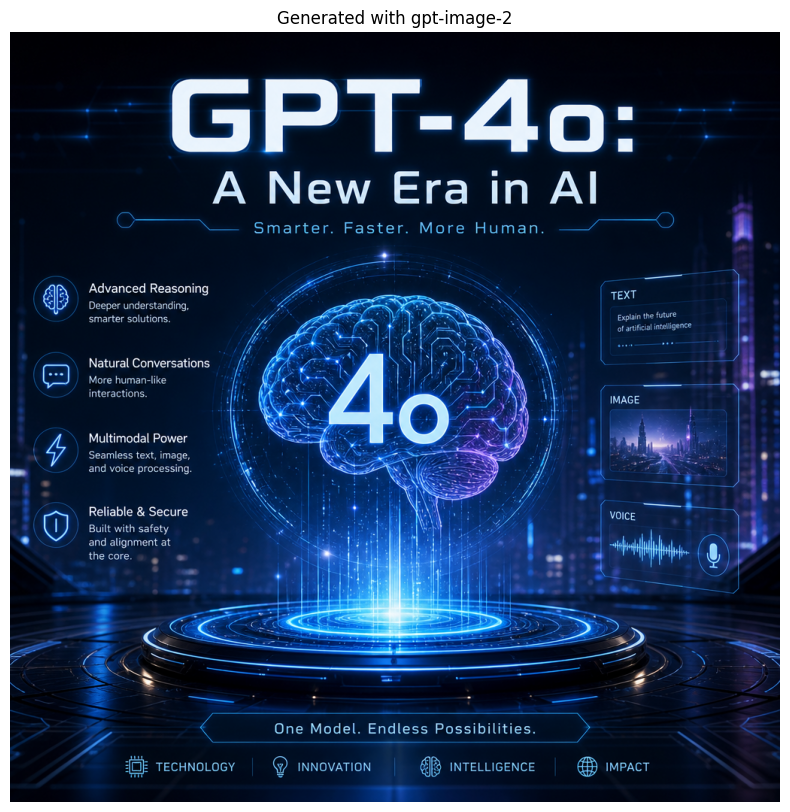

Image saved to: /content/generated_image_gpt-image-2.png



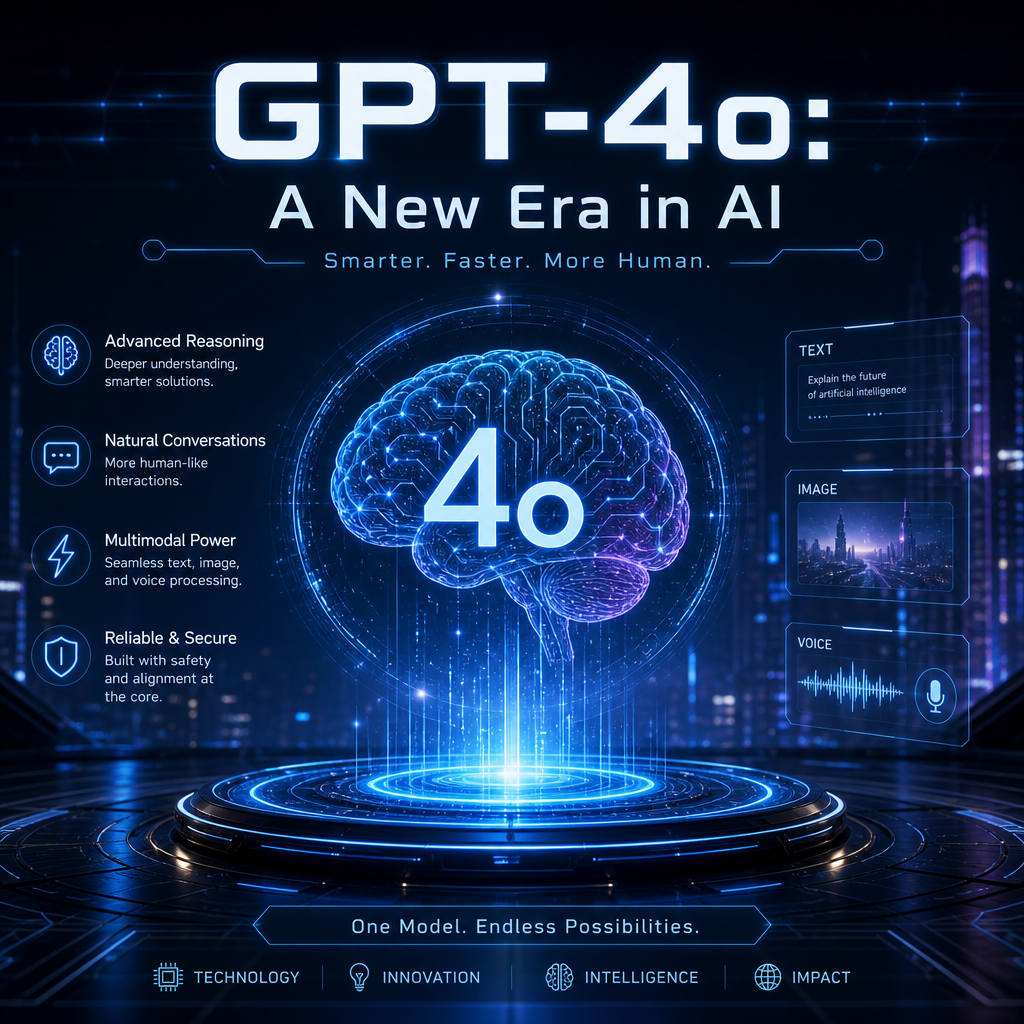


Done!


In [ ]:
import pytz
from datetime import datetime
from openai import OpenAI
import os
import IPython
from google.colab import userdata
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import base64

# Initialize the OpenAI client
api_key = userdata.get('OPENAI_API_KEY')
client = OpenAI(api_key=api_key)

# datetime object containing current date and time
newYorkTz = pytz.timezone("America/New_York")
now = datetime.now(newYorkTz)
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")

print()
print('TEST - OPENAI IMAGE GENERATION - BY FRANK MORALES - %s' % dt_string)
print()

# Generate image with gpt-image-2
model = "gpt-image-2"
prompt = "GENERATE futuristic IMAGE of Title: GPT-4o: A New Era in AI"

print(f"Generating image with {model}...")
print(f"Prompt: {prompt}")
print()

response = client.images.generate(
    model=model,
    prompt=prompt,
    n=1,
    size="1024x1024"
)

# Get the base64 image data
if hasattr(response.data[0], 'b64_json') and response.data[0].b64_json:
    print("✓ Image generated successfully!")

    # Decode base64 to image
    image_data = base64.b64decode(response.data[0].b64_json)
    img = Image.open(BytesIO(image_data))

    # Display with matplotlib
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Generated with {model}", fontsize=12)
    plt.show()

    # Save the image
    save_path = "/content/generated_image_gpt-image-2.png"
    img.save(save_path)
    print(f"Image saved to: {save_path}")

    # Display with HTML inline
    from IPython.display import HTML, display
    buffered = BytesIO()
    img.save(buffered, format="PNG")
    img_base64 = base64.b64encode(buffered.getvalue()).decode()
    display(HTML(f'<img src="data:image/png;base64,{img_base64}" style="max-width: 800px;">'))

else:
    print("No b64_json in response")

print()
print("="*60)
print("Done!")

# TEXT TO AUDIO

In [ ]:
from openai import OpenAI
from warnings import filterwarnings
filterwarnings('ignore')

api_key = userdata.get('OPENAI_API_KEY')
client = OpenAI(api_key=api_key)

response = client.audio.speech.create(
    model="tts-1",
    #model=modelid,
    voice="alloy",
    input="Hello world! This is a streaming test in google colab with Openai API.",
)

response.stream_to_file("output.mp3")

In [ ]:
!ls -ltha /content/output.mp3

-rw-r--r-- 1 root root 69K Sep  7 16:07 /content/output.mp3
